In [29]:
import itertools
import json
import os

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from tqdm.notebook import (
    tqdm, 
    trange,
)

In [26]:
# Вычисление точности
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [2]:
def train_test_plot(X_train, y_train, X_test, y_test, title1="Train", title2="Test"):
    plt.figure(figsize=(16, 7))

    ax = plt.subplot(121)
    plt.title(title1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    _ = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="Set3", ec='black', alpha=0.85, lw=0.5)

    plt.subplot(122, sharex=ax, sharey=ax)
    plt.title(title2)
    plt.xlabel("$x_1$")
    # Если классификатор предсказал вероятность принадлежности первому классу >= 0.5, считаем объект принадлежащим классу 1
    # в противном случае - 0
    _ = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="Set3", ec='black', alpha=0.85, lw=0.5)

In [3]:
import numpy as np

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y."""
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    margin_x1 = (X[:, 0].max() - X[:, 0].min()) * 0.1
    margin_x2 = (X[:, 1].max() - X[:, 1].min()) * 0.1
    
    x_min, x_max = X[:, 0].min() - margin_x1, X[:, 0].max() + margin_x1
    y_min, y_max = X[:, 1].min() - margin_x2, X[:, 1].max() + margin_x2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 501), np.linspace(y_min, y_max, 501))

    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap="Set3", alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap="Set3", ec='black', alpha=1, lw=0.5)
    
    plt.xlabel("$x_0$")
    plt.ylabel("$x_1$")
    
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    
def train_test_model_plot(model, X_train, y_train, X_test, y_test):
    plt.figure(figsize=(16, 7))

    plt.subplot(1, 2, 1)
    plt.title("Train")
    plot_decision_boundary(model, X_train, y_train)

    plt.subplot(1, 2, 2)
    plt.title("Test")
    plot_decision_boundary(model, X_test, y_test)

# labeled data

In [5]:
RANDOM_SEED = 42
IS_RESAMPLE = False
main_path = os.getcwd()
labeling_path = os.path.join(
    main_path,
    'project-1-at-2025-05-13-11-10-34463d27.json'
)
audio_sets_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'Phonetics Project (Praat)'
    )
for _path in (main_path, labeling_path, audio_sets_path):
    display(_path)

'/home/alexeysvatov/projects/ProjectLinguist/jupyter/scripts'

'/home/alexeysvatov/projects/ProjectLinguist/jupyter/scripts/project-1-at-2025-05-13-11-10-34463d27.json'

'/home/alexeysvatov/projects/ProjectLinguist/jupyter/Phonetics Project (Praat)'

In [6]:
def preprocess_audio(audio_file_path, hop_length=256, n_mels=20):
    audio, sr = librosa.load(audio_file_path)
    _preprocessed = {
        'melspectrum': np.mean(librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            hop_length=hop_length, 
            n_mels=n_mels
        ), axis=1),
        'mfcc': np.mean(librosa.feature.mfcc(
            y=audio, 
            sr=sr,
            hop_length=hop_length,
            n_mels=n_mels
        ), axis=1),
        'rolloff': abs(np.mean(librosa.feature.spectral_rolloff(
            y=audio, 
            sr=sr
        ))),
        'zrate': abs(np.mean(librosa.feature.zero_crossing_rate(audio))),
    }
    
    return _preprocessed

In [7]:
labels_df = pd.read_json(labeling_path)
labels_df = labels_df.loc[:, ['file_upload', 'annotations']].explode('annotations', ignore_index=True)
labels_df['file_upload'] = labels_df['file_upload'].apply(lambda _: _.partition('-')[2])
labels_df['result'] = labels_df['annotations'].apply(lambda _: _['result'] if isinstance(_, dict) else _)
labels_df = labels_df.drop('annotations', axis=1).explode('result', ignore_index=True)
labels_df['start'] = labels_df['result'].apply(lambda _: _['value']['start'] if isinstance(_, dict) else _)
labels_df['end'] = labels_df['result'].apply(lambda _: _['value']['end'] if isinstance(_, dict) else _)
labels_df['difference'] = (labels_df['end'] - labels_df['start']) * 1000
labels_df['label'] = labels_df['result'].apply(lambda _: _['value']['labels'] if isinstance(_, dict) else _)
labels_df = labels_df.drop('result', axis=1).explode('label', ignore_index=True)
labels_df = labels_df.loc[(labels_df.label != 'ignore') & (labels_df.label != 'noise') & (labels_df.end - labels_df.start >= 0.1), :]
labels_df['colab_file_path'] = audio_sets_path + '/' + labels_df['file_upload'].str.partition('_')[0] + '_' + labels_df['file_upload'].str.partition('_')[2].str.replace('_', ' ')
labels_df['label'] = pd.Categorical(labels_df['label'])
labels_df['label_id'] = labels_df['label'].cat.codes
labels_df.head()

,file_upload,start,end,difference,label,colab_file_path,label_id
2,1_In_a_restaurant.mp3,5.900917,6.019838,118.921208,stressed_syllable,/home/alexeysvatov/projects/ProjectLinguist/ju...,18
3,1_In_a_restaurant.mp3,6.230580,6.454639,224.059099,stressed_syllable,/home/alexeysvatov/projects/ProjectLinguist/ju...,18
4,1_In_a_restaurant.mp3,6.019880,6.230599,210.718572,plain,/home/alexeysvatov/projects/ProjectLinguist/ju...,15
5,1_In_a_restaurant.mp3,6.454629,6.617893,163.263443,plain,/home/alexeysvatov/projects/ProjectLinguist/ju...,15
6,1_In_a_restaurant.mp3,6.617900,6.870468,252.567449,low_rise,/home/alexeysvatov/projects/ProjectLinguist/ju...,10


In [8]:
# makes labeled slices
labels_df['colab_samples_path'] = None
colab_file_path = None
colab_samples_path = os.path.join(main_path, 'labeled_samples')
for idx in tqdm(labels_df.index):
    audio_slice_file_path = os.path.join(colab_samples_path,
                                         f"{idx}_{labels_df.loc[idx, 'colab_file_path'].split('/')[-1]}")
    labels_df.loc[idx, 'colab_samples_path'] = audio_slice_file_path
    if IS_RESAMPLE:
        if colab_file_path != labels_df.loc[idx, 'colab_file_path']:
            colab_file_path = labels_df.loc[idx, 'colab_file_path']
        audio = AudioSegment.from_mp3(labels_df.loc[idx, 'colab_file_path'])
        start_pos = labels_df.loc[idx, 'start'] * 1000
        end_pos = labels_df.loc[idx, 'end'] * 1000
        audio_slice = audio[start_pos:end_pos]
        audio_slice.export(audio_slice_file_path, format='mp3')
labels_df = labels_df.reset_index(names='old_index')

  0%|          | 0/882 [00:00<?, ?it/s]

In [9]:
data = []
hop_length = 128
n_mels = 40
for csp in labels_df.colab_samples_path:
    data.append(
        {
            'colab_samples_path': csp,
            **preprocess_audio(csp, hop_length=hop_length, n_mels=n_mels)
        }
    )

In [10]:
df = pd.DataFrame(data)

mfcc_columns = [f'mfcc_{idx}' for idx in range(df.mfcc[0].size)]
melspectrum_columns = [f'melspectrum_{idx}' for idx in range(df.melspectrum[0].size)]

df[mfcc_columns] = pd.DataFrame(df.mfcc.tolist(), df.index)
df[melspectrum_columns] = pd.DataFrame(df.melspectrum.tolist(), df.index)
df.head()

,colab_samples_path,melspectrum,mfcc,rolloff,zrate,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,melspectrum_30,melspectrum_31,melspectrum_32,melspectrum_33,melspectrum_34,melspectrum_35,melspectrum_36,melspectrum_37,melspectrum_38,melspectrum_39
0,/home/alexeysvatov/projects/ProjectLinguist/ju...,"[0.015859658, 0.13360345, 23.94255, 40.439667,...","[-105.55614, 111.83503, -19.678083, -9.315444,...",1290.197754,0.046387,-105.556137,111.835030,-19.678083,-9.315444,-14.854431,...,0.000371,0.000027,0.000404,0.000794,0.001419,0.000512,0.000227,0.000078,0.000007,0.000003
1,/home/alexeysvatov/projects/ProjectLinguist/ju...,"[0.26912397, 46.879185, 70.071, 14.877626, 42....","[-71.38629, 102.2122, -25.945858, 7.254818, 6....",2026.274414,0.061426,-71.386292,102.212196,-25.945858,7.254818,6.239717,...,0.000789,0.000760,0.000855,0.000460,0.000621,0.000698,0.000503,0.000890,0.000269,0.000174
2,/home/alexeysvatov/projects/ProjectLinguist/ju...,"[0.16376561, 13.039576, 124.42403, 44.80544, 0...","[-88.1492, 64.30096, -17.069317, 22.782125, 1....",3487.302246,0.047021,-88.149200,64.300957,-17.069317,22.782125,1.987356,...,0.011107,0.007841,0.008501,0.010087,0.009009,0.006633,0.006096,0.001263,0.000523,0.000133
3,/home/alexeysvatov/projects/ProjectLinguist/ju...,"[1.1447085, 12.507581, 19.20927, 60.94485, 4.8...","[-103.95176, 59.761208, -0.5934552, 25.225636,...",3779.077148,0.079346,-103.951759,59.761208,-0.593455,25.225636,7.580552,...,0.015673,0.007521,0.006390,0.008021,0.011789,0.012451,0.002298,0.001521,0.000926,0.000685
4,/home/alexeysvatov/projects/ProjectLinguist/ju...,"[4.029156, 10.177817, 48.085182, 11.019594, 7....","[-122.036545, 68.16472, 7.255043, 40.853554, 9...",3584.299538,0.063477,-122.036545,68.164719,7.255043,40.853554,9.603881,...,0.018823,0.005997,0.002302,0.001437,0.000822,0.000585,0.001291,0.000896,0.001189,0.000204


In [11]:
labels_df = labels_df.join(
    df.loc[:, ~df.columns.isin(['mfcc', 'melspectrum'])], 
    lsuffix='colab_samples_path',
    rsuffix='colab_samples_path',
)
labels_df.head()

,old_index,file_upload,start,end,difference,label,colab_file_path,label_id,colab_samples_pathcolab_samples_path,colab_samples_pathcolab_samples_path,...,melspectrum_30,melspectrum_31,melspectrum_32,melspectrum_33,melspectrum_34,melspectrum_35,melspectrum_36,melspectrum_37,melspectrum_38,melspectrum_39
0,2,1_In_a_restaurant.mp3,5.900917,6.019838,118.921208,stressed_syllable,/home/alexeysvatov/projects/ProjectLinguist/ju...,18,/home/alexeysvatov/projects/ProjectLinguist/ju...,/home/alexeysvatov/projects/ProjectLinguist/ju...,...,0.000371,0.000027,0.000404,0.000794,0.001419,0.000512,0.000227,0.000078,0.000007,0.000003
1,3,1_In_a_restaurant.mp3,6.230580,6.454639,224.059099,stressed_syllable,/home/alexeysvatov/projects/ProjectLinguist/ju...,18,/home/alexeysvatov/projects/ProjectLinguist/ju...,/home/alexeysvatov/projects/ProjectLinguist/ju...,...,0.000789,0.000760,0.000855,0.000460,0.000621,0.000698,0.000503,0.000890,0.000269,0.000174
2,4,1_In_a_restaurant.mp3,6.019880,6.230599,210.718572,plain,/home/alexeysvatov/projects/ProjectLinguist/ju...,15,/home/alexeysvatov/projects/ProjectLinguist/ju...,/home/alexeysvatov/projects/ProjectLinguist/ju...,...,0.011107,0.007841,0.008501,0.010087,0.009009,0.006633,0.006096,0.001263,0.000523,0.000133
3,5,1_In_a_restaurant.mp3,6.454629,6.617893,163.263443,plain,/home/alexeysvatov/projects/ProjectLinguist/ju...,15,/home/alexeysvatov/projects/ProjectLinguist/ju...,/home/alexeysvatov/projects/ProjectLinguist/ju...,...,0.015673,0.007521,0.006390,0.008021,0.011789,0.012451,0.002298,0.001521,0.000926,0.000685
4,6,1_In_a_restaurant.mp3,6.617900,6.870468,252.567449,low_rise,/home/alexeysvatov/projects/ProjectLinguist/ju...,10,/home/alexeysvatov/projects/ProjectLinguist/ju...,/home/alexeysvatov/projects/ProjectLinguist/ju...,...,0.018823,0.005997,0.002302,0.001437,0.000822,0.000585,0.001291,0.000896,0.001189,0.000204


# learning

In [12]:
X_cols = ['rolloff', 'zrate', *mfcc_columns, *melspectrum_columns]
X = labels_df.loc[:, X_cols]
y = labels_df.label_id

# Преобразование в тензоры
X_torch = torch.tensor(X.values).type(torch.float)
y_torch = torch.tensor(y.values).type(torch.LongTensor)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_torch,
    y_torch,
    test_size=0.2,
    random_state=RANDOM_SEED
)

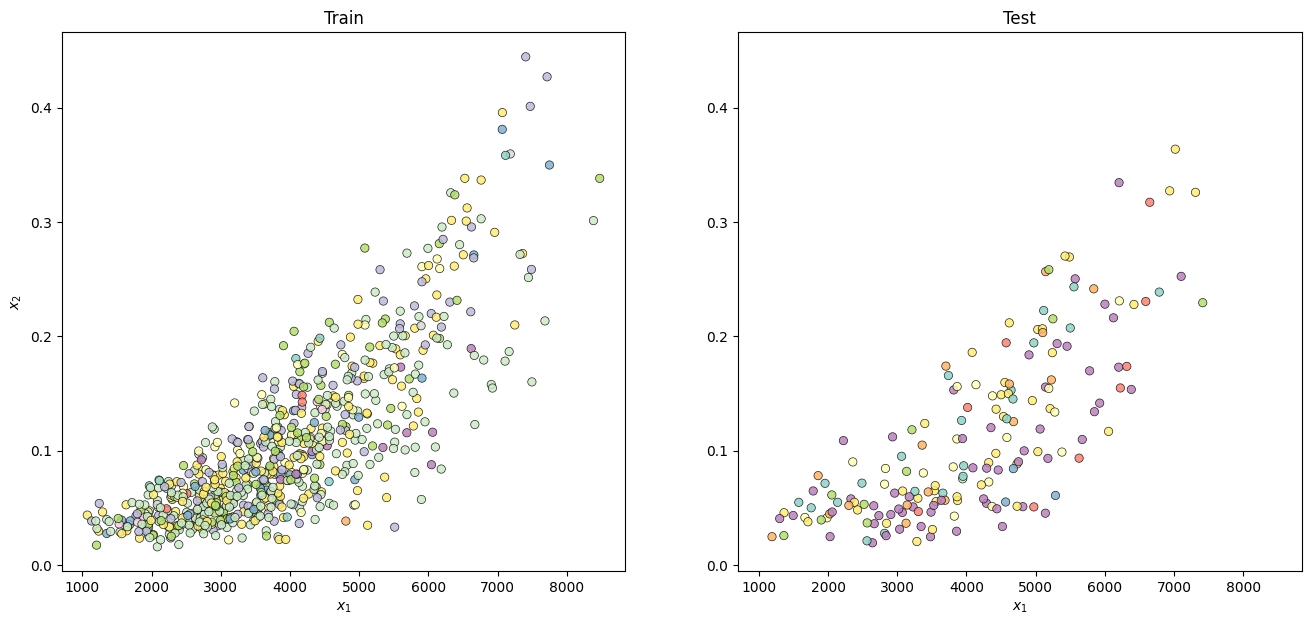

In [14]:
train_test_plot(X_train, y_train, X_test, y_test)

In [15]:
class MulticlassClassification(torch.nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = torch.nn.Sequential(
            torch.nn.Linear(in_features=input_features, out_features=hidden_units),
            torch.nn.ReLU(), # <- нелинейные преобразования
            torch.nn.Linear(in_features=hidden_units, out_features=hidden_units),
            torch.nn.ReLU(), # <- нелинейные преобразования
            torch.nn.Linear(in_features=hidden_units, out_features=output_features),
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)

In [47]:
class AudioClassifier(nn.Module):
    # ----------------------------
    # Build the model architecture
    # ----------------------------
    def __init__(self, in_features, out_features):
        super().__init__()
        conv_layers = []

        # First Convolution Block with Relu and Batch Norm. Use Kaiming Initialization
        self.conv1 = nn.Conv2d(in_features, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2)) # for 2 channels
        self.relu1 = nn.ReLU()
        # self.sig1 = nn.Sigmoid()
        self.bn1 = nn.BatchNorm2d(8)
        nn.init.kaiming_normal_(self.conv1.weight, a=0.1)
        self.conv1.bias.data.zero_()
        conv_layers += [
            self.conv1, 
            self.relu1, 
            # self.sig1,
            self.bn1,
        ]

        # Second Convolution Block
        self.conv2 = nn.Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) # for 2 channels
        self.relu2 = nn.ReLU()
        # self.sig2 = nn.Sigmoid()
        self.bn2 = nn.BatchNorm2d(16)
        nn.init.kaiming_normal_(self.conv2.weight, a=0.1)
        self.conv2.bias.data.zero_()
        conv_layers += [
            self.conv2, 
            self.relu2, 
            # self.sig2, 
            self.bn2,
        ]

        # Third Convolution Block
        self.conv3 = nn.Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) # for 2 channels
        self.relu3 = nn.ReLU()
        # self.sig3 = nn.Sigmoid()
        self.bn3 = nn.BatchNorm2d(32)
        nn.init.kaiming_normal_(self.conv3.weight, a=0.1)
        self.conv3.bias.data.zero_()
        conv_layers += [
            self.conv3, 
            self.relu3, 
            # self.sig3,
            self.bn3,
        ]

        # Fourth Convolution Block
        self.conv4 = nn.Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) # for 2 channels
        # self.relu4 = nn.ReLU()
        self.sig4 = nn.Sigmoid()
        self.bn4 = nn.BatchNorm2d(64)
        nn.init.kaiming_normal_(self.conv4.weight, a=0.1)
        self.conv4.bias.data.zero_()
        conv_layers += [
            self.conv4, 
            # self.relu4, 
            self.sig4,
            self.bn4
        ]

        # # Fifth Convolution Block
        # self.conv5 = nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) # for 2 channels
        # # self.relu5 = nn.ReLU()
        # self.sig5 = nn.Sigmoid()
        # self.bn5 = nn.BatchNorm2d(128)
        # nn.init.kaiming_normal_(self.conv5.weight, a=0.1)
        # self.conv5.bias.data.zero_()
        # conv_layers += [
        #     self.conv5, 
        #     # self.relu5, 
        #     self.sig5,
        #     self.bn5
        # ]

        # Linear Classifier
        self.ap = nn.AdaptiveAvgPool2d(output_size=1)
        self.lin = nn.Linear(in_features=64, out_features=out_features)

        # Wrap the Convolutional Blocks
        self.conv = nn.Sequential(*conv_layers)

    # ----------------------------
    # Forward pass computations
    # ----------------------------
    def forward(self, x):
        # Run the convolutional blocks
        x = self.conv(x)

        # Adaptive pool and flatten for input to linear layer
        x = self.ap(x)
        x = x.view(x.shape[0], -1)

        # Linear layer
        x = self.lin(x)

        # Final output
        return x

In [23]:
NUM_FEATURES = X_torch.shape[1]
# NUM_FEATURES = 2
NUM_CLASSES = y_torch.unique().shape[0]
HIDDEN_UNITS = 8
model = MulticlassClassification(input_features=NUM_FEATURES, 
                                 output_features=NUM_CLASSES, 
                                 hidden_units=HIDDEN_UNITS)
display(model)
# Опишем функцию потерь и оптимизатор
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), 
                            lr=0.1) # Попробуйте различные learning_rate

MulticlassClassification(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=62, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=19, bias=True)
  )
)

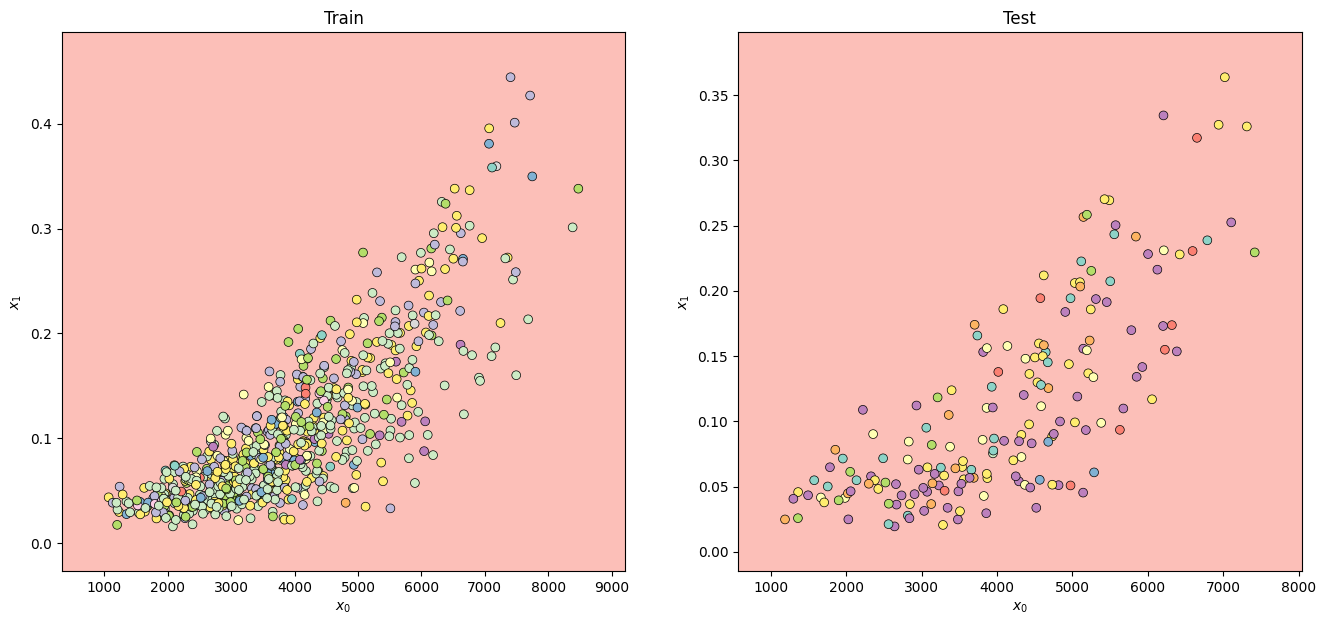

In [17]:
train_test_model_plot(model, X_train, y_train, 
                             X_test, y_test)

In [24]:
def learn_milticlass_classification_model(model, n_epochs, print_every_epoch=None):
    if print_every_epoch is None:
        print_every_epoch = n_epochs / 10
    
    torch.manual_seed(42)

    for epoch in range(n_epochs):
        ### Обучение
        model.train()

        y_logits = model(X_train)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        
        loss = loss_fn(y_logits, y_train) 
        acc = accuracy_fn(y_true=y_train,
                          y_pred=y_pred)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        ### Тестирование
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
            
            test_loss = loss_fn(test_logits, y_test)
            test_acc = accuracy_fn(y_true=y_test,
                                 y_pred=test_pred)

        # Print out what's happening
        if epoch % print_every_epoch == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%") 

In [28]:
learn_milticlass_classification_model(model, 1000, 50)

Epoch: 0 | Loss: 2.28300, Acc: 36.31% | Test Loss: 2.30983, Test Acc: 31.64%
Epoch: 50 | Loss: 2.25567, Acc: 36.31% | Test Loss: 2.27972, Test Acc: 31.64%
Epoch: 100 | Loss: 2.23523, Acc: 36.31% | Test Loss: 2.25885, Test Acc: 31.64%
Epoch: 150 | Loss: 2.21896, Acc: 36.31% | Test Loss: 2.24363, Test Acc: 31.64%
Epoch: 200 | Loss: 2.20540, Acc: 36.31% | Test Loss: 2.23203, Test Acc: 31.64%
Epoch: 250 | Loss: 2.19370, Acc: 36.31% | Test Loss: 2.22287, Test Acc: 31.64%
Epoch: 300 | Loss: 2.18339, Acc: 36.31% | Test Loss: 2.21543, Test Acc: 31.64%
Epoch: 350 | Loss: 2.17421, Acc: 36.31% | Test Loss: 2.20926, Test Acc: 31.64%
Epoch: 400 | Loss: 2.16603, Acc: 36.31% | Test Loss: 2.20407, Test Acc: 31.64%
Epoch: 450 | Loss: 2.15876, Acc: 36.31% | Test Loss: 2.19967, Test Acc: 31.64%
Epoch: 500 | Loss: 2.15238, Acc: 36.31% | Test Loss: 2.19593, Test Acc: 31.64%
Epoch: 550 | Loss: 2.14683, Acc: 36.31% | Test Loss: 2.19274, Test Acc: 31.64%
Epoch: 600 | Loss: 2.14205, Acc: 36.31% | Test Loss: 2.

In [52]:
cnn_model = AudioClassifier(in_features=NUM_FEATURES, out_features=NUM_CLASSES)

In [53]:
learn_milticlass_classification_model(cnn_model, 100, 10)

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [705, 62]